# Daniyal Khan || 221A061 || 19

In [ ]:
# Daniyal Khan || 19
!pip install requests pandas

In [3]:
# Daniyal Khan || 19
import requests
import pandas as pd
import re
import json

In [4]:
# Daniyal Khan || 19
search_query = "Web Development React"
url = "https://www.youtube.com/results?search_query=" + search_query.replace(" ", "+")

In [5]:
# Daniyal Khan || 19
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
html = response.text

In [6]:
# Daniyal Khan || 19
pattern = r"var ytInitialData = (.*?);</script>"
match = re.search(pattern, html)

data = []
if match:
    json_data = json.loads(match.group(1))

    contents = json_data["contents"]["twoColumnSearchResultsRenderer"] \
        ["primaryContents"]["sectionListRenderer"]["contents"]

    for section in contents:
        items = section.get("itemSectionRenderer", {}).get("contents", [])
        for item in items:
            if "videoRenderer" in item:
                video = item["videoRenderer"]
                title = video["title"]["runs"][0]["text"]
                video_id = video["videoId"]
                link = "https://www.youtube.com/watch?v=" + video_id
                data.append([title, link])


In [7]:
# Daniyal Khan || 19
df = pd.DataFrame(data, columns=["Video Title", "Video Link"])
df.head()


,Video Title,Video Link
0,React JS Explained In 10 Minutes,https://www.youtube.com/watch?v=s2skans2dP4
1,React Tutorial for Beginners,https://www.youtube.com/watch?v=SqcY0GlETPk
2,Every React Concept Explained in 12 Minutes,https://www.youtube.com/watch?v=wIyHSOugGGw
3,React Tutorial Full Course - Beginner to Pro (...,https://www.youtube.com/watch?v=TtPXvEcE11E
4,React in 100 Seconds,https://www.youtube.com/watch?v=Tn6-PIqc4UM


In [8]:
# Daniyal Khan || 19
df.to_csv("youtube_business_data.csv", index=False)
print("CSV file saved successfully with", len(df), "records")


CSV file saved successfully with 17 records


## Part 2 Of Filtering

In [9]:
# Daniyal Khan || 19
df = pd.read_csv("youtube_business_data.csv")
df.head()

,Video Title,Video Link
0,React JS Explained In 10 Minutes,https://www.youtube.com/watch?v=s2skans2dP4
1,React Tutorial for Beginners,https://www.youtube.com/watch?v=SqcY0GlETPk
2,Every React Concept Explained in 12 Minutes,https://www.youtube.com/watch?v=wIyHSOugGGw
3,React Tutorial Full Course - Beginner to Pro (...,https://www.youtube.com/watch?v=TtPXvEcE11E
4,React in 100 Seconds,https://www.youtube.com/watch?v=Tn6-PIqc4UM


In [10]:
# Daniyal Khan || 19
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [11]:

# Daniyal Khan || 19
df["Clean_Title"] = df["Video Title"].apply(clean_text)
df.head()

,Video Title,Video Link,Clean_Title
0,React JS Explained In 10 Minutes,https://www.youtube.com/watch?v=s2skans2dP4,react js explained in minutes
1,React Tutorial for Beginners,https://www.youtube.com/watch?v=SqcY0GlETPk,react tutorial for beginners
2,Every React Concept Explained in 12 Minutes,https://www.youtube.com/watch?v=wIyHSOugGGw,every react concept explained in minutes
3,React Tutorial Full Course - Beginner to Pro (...,https://www.youtube.com/watch?v=TtPXvEcE11E,react tutorial full course beginner to pro react
4,React in 100 Seconds,https://www.youtube.com/watch?v=Tn6-PIqc4UM,react in seconds


In [12]:
# Daniyal Khan || 19
df = df.drop_duplicates(subset="Clean_Title")

In [13]:
# Daniyal Khan || 19
youtube_keywords = [
    "React","beginner","course"
]


df["Business_Relevant"] = df["Clean_Title"].apply(
    lambda x: any(word in x for word in youtube_keywords)
)


filtered_df = df[df["Business_Relevant"] == True]
filtered_df.head()


,Video Title,Video Link,Clean_Title,Business_Relevant
1,React Tutorial for Beginners,https://www.youtube.com/watch?v=SqcY0GlETPk,react tutorial for beginners,True
3,React Tutorial Full Course - Beginner to Pro (...,https://www.youtube.com/watch?v=TtPXvEcE11E,react tutorial full course beginner to pro react,True
7,React Full Course for free ⚛️,https://www.youtube.com/watch?v=CgkZ7MvWUAA,react full course for free,True
9,React JS 19 Full Course 2025 | Build an App an...,https://www.youtube.com/watch?v=dCLhUialKPQ,react js full course build an app and master r...,True
14,Learn React JS - Full Beginner’s Tutorial & Pr...,https://www.youtube.com/watch?v=x4rFhThSX04,learn react js full beginners tutorial practic...,True


In [14]:
# Daniyal Khan || 19
filtered_df.reset_index(drop=True, inplace=True)

In [15]:
# Daniyal Khan || 19
filtered_df.to_csv("youtube_business_data_cleaned.csv", index=False)


print("Cleaning completed successfully")
print("Total cleaned records:", len(filtered_df))
print("Filtered Record", filtered_df)

Cleaning completed successfully
Total cleaned records: 6
Filtered Record                                          Video Title  \
0                       React Tutorial for Beginners   
1  React Tutorial Full Course - Beginner to Pro (...   
2                      React Full Course for free ⚛️   
3  React JS 19 Full Course 2025 | Build an App an...   
4  Learn React JS - Full Beginner’s Tutorial & Pr...   
5            React JS - React Tutorial for Beginners   

                                    Video Link  \
0  https://www.youtube.com/watch?v=SqcY0GlETPk   
1  https://www.youtube.com/watch?v=TtPXvEcE11E   
2  https://www.youtube.com/watch?v=CgkZ7MvWUAA   
3  https://www.youtube.com/watch?v=dCLhUialKPQ   
4  https://www.youtube.com/watch?v=x4rFhThSX04   
5  https://www.youtube.com/watch?v=Ke90Tje7VS0   

                                         Clean_Title  Business_Relevant  
0                       react tutorial for beginners               True  
1   react tutorial full course begi

# Part 3 (EDA)

In [60]:
# Daniyal Khan || 19
# Shape of the dataset
print("Dataset Shape:", filtered_df.shape)

# Column information
filtered_df.info()

# Check missing values
filtered_df.isnull().sum()


Dataset Shape: (5, 6)
<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 5 to 14
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Blog Title         5 non-null      object
 1   Tags/Topics        5 non-null      object
 2   Clean_Title        5 non-null      object
 3   Business_Relevant  5 non-null      bool  
 4   React_Relevant     5 non-null      bool  
 5   Title_Length       5 non-null      int64 
dtypes: bool(2), int64(1), object(3)
memory usage: 210.0+ bytes


,0
Blog Title,0
Tags/Topics,0
Clean_Title,0
Business_Relevant,0
React_Relevant,0
Title_Length,0


In [61]:
# Daniyal Khan || 19
filtered_df.describe(include="all")

,Blog Title,Tags/Topics,Clean_Title,Business_Relevant,React_Relevant,Title_Length
count,5,5,5,5,5,5.000000
unique,5,5,5,1,1,NaN
top,JavaScript Basic Array Methods,"#javascript, #beginners, #tutorial",javascript basic array methods,True,True,NaN
freq,1,1,1,5,5,NaN
mean,NaN,NaN,NaN,NaN,NaN,56.800000
std,NaN,NaN,NaN,NaN,NaN,36.982428
min,NaN,NaN,NaN,NaN,NaN,30.000000
25%,NaN,NaN,NaN,NaN,NaN,33.000000
50%,NaN,NaN,NaN,NaN,NaN,43.000000
75%,NaN,NaN,NaN,NaN,NaN,58.000000


In [ ]:
# Daniyal Khan || 19
# Length of each cleaned title
filtered_df["Title_Length"] = filtered_df["Clean_Title"].apply(len)

filtered_df[["Video Title", "Title_Length"]].head()


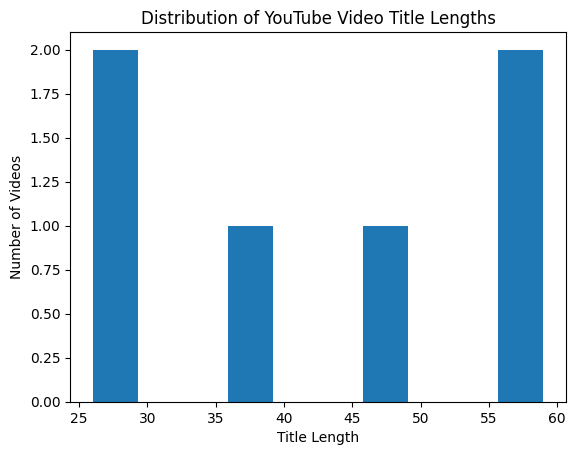

In [21]:
# Daniyal Khan || 19
import matplotlib.pyplot as plt

plt.figure()
plt.hist(filtered_df["Title_Length"], bins=10)
plt.xlabel("Title Length")
plt.ylabel("Number of Videos")
plt.title("Distribution of YouTube Video Title Lengths")
plt.show()


In [22]:
# Daniyal Khan || 19
from collections import Counter

all_words = " ".join(filtered_df["Clean_Title"]).split()
word_freq = Counter(all_words)

# Convert to DataFrame
word_freq_df = pd.DataFrame(word_freq.items(), columns=["Word", "Frequency"])
word_freq_df = word_freq_df.sort_values(by="Frequency", ascending=False)

word_freq_df.head(10)


,Word,Frequency
0,react,9
1,tutorial,4
4,full,4
2,for,3
3,beginners,3
5,course,3
10,js,3
7,to,1
6,beginner,1
8,pro,1


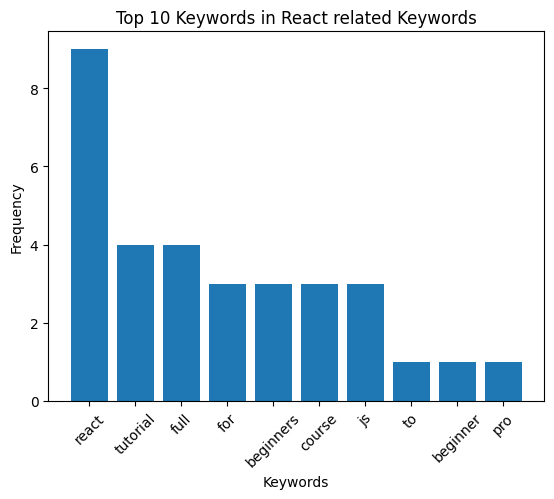

In [28]:
# Daniyal Khan || 19
top_words = word_freq_df.head(10)

plt.figure()
plt.bar(top_words["Word"], top_words["Frequency"])
plt.xlabel("Keywords")
plt.ylabel("Frequency")
plt.title("Top 10 Keywords in React related Keywords")
plt.xticks(rotation=45)
plt.show()


In [30]:
# Daniyal Khan || 19
filtered_df["Business_Relevant"].value_counts()

,count
Business_Relevant,
True,6


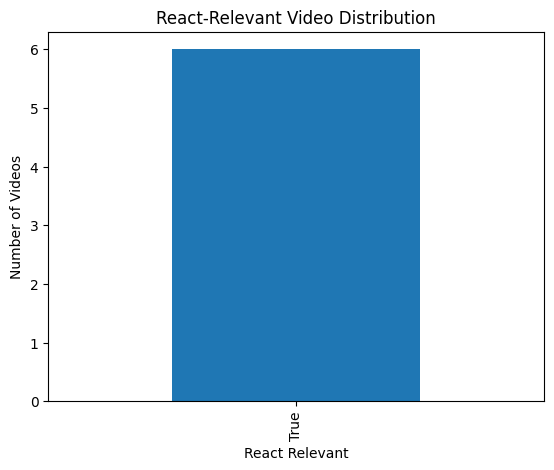

In [32]:
# Daniyal Khan || 19
plt.figure()
filtered_df["Business_Relevant"].value_counts().plot(kind="bar")
plt.xlabel("React Relevant")
plt.ylabel("Number of Videos")
plt.title("React-Relevant Video Distribution")
plt.show()


In [26]:
# Daniyal Khan || 19
filtered_df.head()

,Video Title,Video Link,Clean_Title,Business_Relevant,Title_Length
0,React Tutorial for Beginners,https://www.youtube.com/watch?v=SqcY0GlETPk,react tutorial for beginners,True,28
1,React Tutorial Full Course - Beginner to Pro (...,https://www.youtube.com/watch?v=TtPXvEcE11E,react tutorial full course beginner to pro react,True,48
2,React Full Course for free ⚛️,https://www.youtube.com/watch?v=CgkZ7MvWUAA,react full course for free,True,26
3,React JS 19 Full Course 2025 | Build an App an...,https://www.youtube.com/watch?v=dCLhUialKPQ,react js full course build an app and master r...,True,59
4,Learn React JS - Full Beginner’s Tutorial & Pr...,https://www.youtube.com/watch?v=x4rFhThSX04,learn react js full beginners tutorial practic...,True,56


In [27]:
# Daniyal Khan || 19
filtered_df.to_csv("eda_for_youtube_video.csv", index=False)
print("EDA completed and file saved successfully")


EDA completed and file saved successfully


## Blogs analysis Medium

In [ ]:
# Daniyal Khan || 19
!pip install requests pandas beautifulsoup4

In [34]:
# Daniyal Khan || 19
import requests
from bs4 import BeautifulSoup
import pandas as pd

def get_marketing_blogs(keyword="javascript"):
    print(f"Fetching latest blog posts for: {keyword}...")

    # Dev.to is great for scraping because they keep their data accessible
    url = f"https://dev.to/t/{keyword}"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }

    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        return f"Error: Received status code {response.status_code}"

    soup = BeautifulSoup(response.text, 'html.parser')

    # Find all article cards
    articles = soup.find_all('div', class_='crayons-story')

    blog_data = []

    for post in articles:
        try:
            # 1. Map Title
            title_tag = post.find('h2', class_='crayons-story__title')
            title = title_tag.text.strip() if title_tag else "N/A"

            # 2. Map Link
            link_tag = title_tag.find('a') if title_tag else None
            link = "https://dev.to" + link_tag['href'] if link_tag else "N/A"

            # 3. Map Description / Metadata
            # On Dev.to, we can grab the tags and the date as the 'description' data
            tags = [tag.text.strip() for tag in post.find_all('a', class_='crayons-tag')]
            tag_str = ", ".join(tags)

            # 4. Map Author
            author = post.find('a', class_='crayons-story__secondary').text.strip() if post.find('a', class_='crayons-story__secondary') else "Unknown"

            if title != "N/A":
                blog_data.append({
                    "Blog Title": title,
                    "Tags/Topics": tag_str,

                })
        except Exception as e:
            continue

    return pd.DataFrame(blog_data)


In [35]:
# Daniyal Khan || 19

df = get_marketing_blogs("javascript")

if not df.empty:
    # Save to CSV
    df.to_csv("updated_blog_data.csv", index=False)

    print(f"Success! Found {len(df)} blog posts.\n")

    # Format table display
    display(
        df.head(10).style
        .set_properties(**{
            "text-align": "left",
            "white-space": "pre-wrap"
        })
        .set_table_styles([
            {"selector": "th", "props": [("font-weight", "bold")]}
        ])
    )
else:
    print("Still no data. The website structure might have changed slightly.")


Fetching latest blog posts for: javascript...
Success! Found 15 blog posts.



,Blog Title,Tags/Topics
0,I built WhaleLook - a Solana crypto wallet tracker to work with API's more (feedback wanted),"#webdev, #programming, #javascript, #beginners"
1,You don't need CSS preprocessor,"#webdev, #css, #javascript, #frontend"
2,Building a “Bflix-Style” Streaming Backend with Python (FastAPI + Async Magic),"#webdev, #ai, #programming, #javascript"
3,Why I use Typetify: A Type-Safe Alternative to Lodash,"#webdev, #javascript, #typescript, #opensource"
4,Top Vibe Coding Platforms You Should Try This Year🫵,"#webdev, #programming, #productivity, #javascript"
5,JavaScript Basic Array Methods,"#javascript, #beginners, #tutorial"
6,How to organize your Electron project with Modules,"#showdev, #javascript, #electron, #opensource"
7,Hands-On Workshop: Refactoring Anti-Patterns,"#webdev, #react, #javascript, #typescript"
8,CReact: JSX meta-execution engine v0.3.0,"#ai, #automation, #programming, #javascript"
9,"Building IRS Ireland: C++ at the Core, the Problems We Faced, and Our Future Goals","#webdev, #ai, #programming, #javascript"


## Part 2 Of Blogs Filtering

In [36]:
# Daniyal Khan || 19
df = pd.read_csv("updated_blog_data.csv")
df.head()

,Blog Title,Tags/Topics
0,I built WhaleLook - a Solana crypto wallet tra...,"#webdev, #programming, #javascript, #beginners"
1,You don't need CSS preprocessor,"#webdev, #css, #javascript, #frontend"
2,Building a “Bflix-Style” Streaming Backend wit...,"#webdev, #ai, #programming, #javascript"
3,Why I use Typetify: A Type-Safe Alternative to...,"#webdev, #javascript, #typescript, #opensource"
4,Top Vibe Coding Platforms You Should Try This ...,"#webdev, #programming, #productivity, #javascript"


In [37]:
# Daniyal Khan || 19
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [38]:
# Daniyal Khan || 19
df["Clean_Title"] = df["Blog Title"].apply(clean_text)
df.head()

,Blog Title,Tags/Topics,Clean_Title
0,I built WhaleLook - a Solana crypto wallet tra...,"#webdev, #programming, #javascript, #beginners",i built whalelook a solana crypto wallet track...
1,You don't need CSS preprocessor,"#webdev, #css, #javascript, #frontend",you dont need css preprocessor
2,Building a “Bflix-Style” Streaming Backend wit...,"#webdev, #ai, #programming, #javascript",building a bflixstyle streaming backend with p...
3,Why I use Typetify: A Type-Safe Alternative to...,"#webdev, #javascript, #typescript, #opensource",why i use typetify a typesafe alternative to l...
4,Top Vibe Coding Platforms You Should Try This ...,"#webdev, #programming, #productivity, #javascript",top vibe coding platforms you should try this ...


In [39]:
# Daniyal Khan || 19
df = df.drop_duplicates(subset="Clean_Title")

In [42]:
# Daniyal Khan || 19
blog_keywords = [
    "javascript","react","beginner","course"
]


df["React_Relevant"] = df["Clean_Title"].apply(
    lambda x: any(word in x for word in blog_keywords)
)


filtered_df_blog = df[df["React_Relevant"] == True]
filtered_df_blog.head()


,Blog Title,Tags/Topics,Clean_Title,Business_Relevant,React_Relevant
5,JavaScript Basic Array Methods,"#javascript, #beginners, #tutorial",javascript basic array methods,True,True
8,CReact: JSX meta-execution engine v0.3.0,"#ai, #automation, #programming, #javascript",creact jsx metaexecution engine v,True,True
11,Arquitetura Limpa e Injeção de Dependência no ...,"#architecture, #frontend, #javascript, #vue",arquitetura limpa e injeção de dependência no ...,True,True
13,ReactJS Design Pattern ~Optimistic UI Update~,"#programming, #javascript, #react, #learning",reactjs design pattern optimistic ui update,True,True
14,React vs Next.js in 2026: Which One Should Dev...,"#react, #nextjs, #webdev, #javascript",react vs nextjs in which one should developers...,True,True


In [43]:
# Daniyal Khan || 19
filtered_df_blog.reset_index(drop=True, inplace=True)

In [44]:
# Daniyal Khan || 19
filtered_df_blog.to_csv("updated_blog_data_cleaned.csv", index=False)


print("Cleaning completed successfully")
print("Total cleaned records:", len(filtered_df_blog))

Cleaning completed successfully
Total cleaned records: 5


In [45]:
# Daniyal Khan || 19
print("Filtered Record", filtered_df_blog)

Filtered Record                                           Blog Title  \
0                     JavaScript Basic Array Methods   
1           CReact: JSX meta-execution engine v0.3.0   
2  Arquitetura Limpa e Injeção de Dependência no ...   
3      ReactJS Design Pattern ~Optimistic UI Update~   
4  React vs Next.js in 2026: Which One Should Dev...   

                                    Tags/Topics  \
0            #javascript, #beginners, #tutorial   
1   #ai, #automation, #programming, #javascript   
2   #architecture, #frontend, #javascript, #vue   
3  #programming, #javascript, #react, #learning   
4         #react, #nextjs, #webdev, #javascript   

                                         Clean_Title  Business_Relevant  \
0                     javascript basic array methods               True   
1                  creact jsx metaexecution engine v               True   
2  arquitetura limpa e injeção de dependência no ...               True   
3        reactjs design pattern optimist

# Part 3 (EDA for blogs)

In [46]:
# Daniyal Khan || 19
# Shape of the dataset
print("Dataset Shape:", filtered_df_blog.shape)

# Column information
filtered_df_blog.info()

# Check missing values
filtered_df_blog.isnull().sum()


Dataset Shape: (5, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Blog Title         5 non-null      object
 1   Tags/Topics        5 non-null      object
 2   Clean_Title        5 non-null      object
 3   Business_Relevant  5 non-null      bool  
 4   React_Relevant     5 non-null      bool  
dtypes: bool(2), object(3)
memory usage: 262.0+ bytes


,0
Blog Title,0
Tags/Topics,0
Clean_Title,0
Business_Relevant,0
React_Relevant,0


In [48]:
# Daniyal Khan || 19
filtered_df_blog.describe(include="all")

,Blog Title,Tags/Topics,Clean_Title,Business_Relevant,React_Relevant
count,5,5,5,5,5
unique,5,5,5,1,1
top,JavaScript Basic Array Methods,"#javascript, #beginners, #tutorial",javascript basic array methods,True,True
freq,1,1,1,5,5


In [51]:
# Daniyal Khan || 19
# Length of each cleaned title
filtered_df_blog["Title_Length"] = filtered_df_blog["Clean_Title"].apply(len)

filtered_df_blog[["Blog Title", "Title_Length"]].head()


/tmp/ipython-input-1538120135.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_blog["Title_Length"] = filtered_df_blog["Clean_Title"].apply(len)


,Blog Title,Title_Length
0,JavaScript Basic Array Methods,30
1,CReact: JSX meta-execution engine v0.3.0,33
2,Arquitetura Limpa e Injeção de Dependência no ...,120
3,ReactJS Design Pattern ~Optimistic UI Update~,43
4,React vs Next.js in 2026: Which One Should Dev...,58


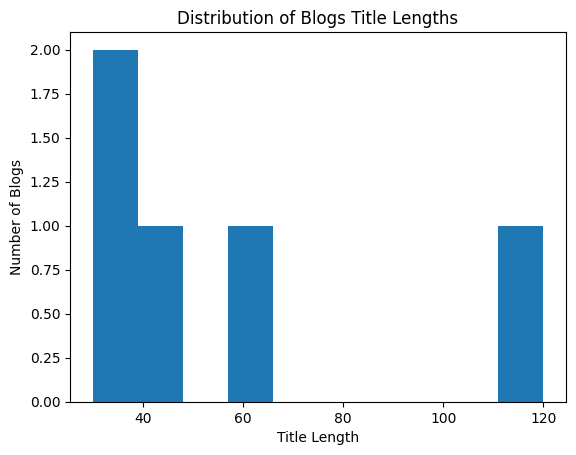

In [52]:
# Daniyal Khan || 19
import matplotlib.pyplot as plt

plt.figure()
plt.hist(filtered_df["Title_Length"], bins=10)
plt.xlabel("Title Length")
plt.ylabel("Number of Blogs")
plt.title("Distribution of Blogs Title Lengths")
plt.show()


In [53]:
# Daniyal Khan || 19
from collections import Counter

all_words = " ".join(filtered_df_blog["Clean_Title"]).split()
word_freq = Counter(all_words)

# Convert to DataFrame
word_freq_df = pd.DataFrame(word_freq.items(), columns=["Word", "Frequency"])
word_freq_df = word_freq_df.sort_values(by="Frequency", ascending=False)

word_freq_df.head(10)


,Word,Frequency
0,javascript,2
13,de,2
2,array,1
1,basic,1
4,creact,1
5,jsx,1
6,metaexecution,1
3,methods,1
7,engine,1
8,v,1


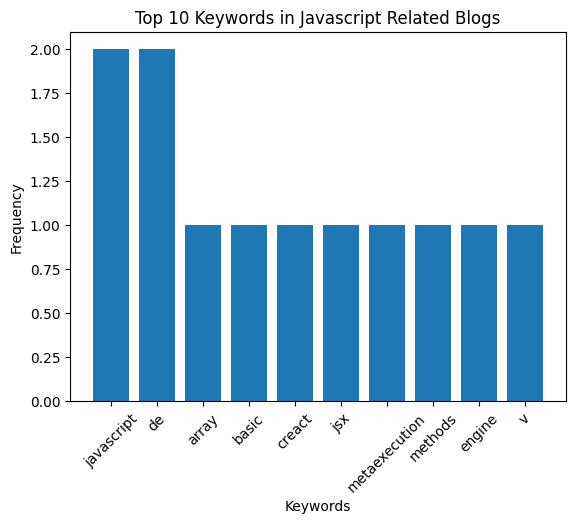

In [54]:
# Daniyal Khan || 19
top_words = word_freq_df.head(10)

plt.figure()
plt.bar(top_words["Word"], top_words["Frequency"])
plt.xlabel("Keywords")
plt.ylabel("Frequency")
plt.title("Top 10 Keywords in Javascript Related Blogs")
plt.xticks(rotation=45)
plt.show()


In [55]:
# Daniyal Khan || 19
filtered_df["React_Relevant"].value_counts()

,count
React_Relevant,
True,5


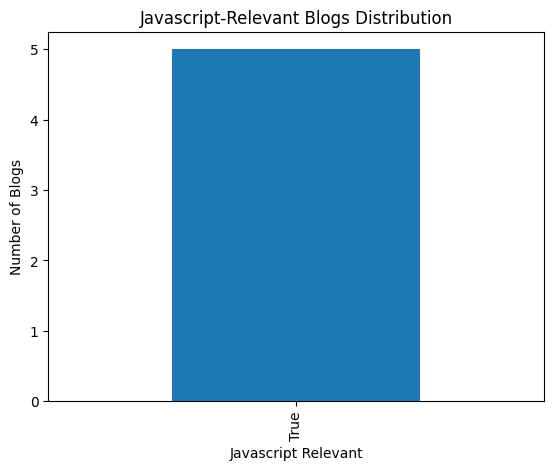

In [57]:
# Daniyal Khan || 19
plt.figure()
filtered_df["React_Relevant"].value_counts().plot(kind="bar")
plt.xlabel("Javascript Relevant")
plt.ylabel("Number of Blogs")
plt.title("Javascript-Relevant Blogs Distribution")
plt.show()


In [58]:
# Daniyal Khan || 19
filtered_df.head()

,Blog Title,Tags/Topics,Clean_Title,Business_Relevant,React_Relevant,Title_Length
5,JavaScript Basic Array Methods,"#javascript, #beginners, #tutorial",javascript basic array methods,True,True,30
8,CReact: JSX meta-execution engine v0.3.0,"#ai, #automation, #programming, #javascript",creact jsx metaexecution engine v,True,True,33
11,Arquitetura Limpa e Injeção de Dependência no ...,"#architecture, #frontend, #javascript, #vue",arquitetura limpa e injeção de dependência no ...,True,True,120
13,ReactJS Design Pattern ~Optimistic UI Update~,"#programming, #javascript, #react, #learning",reactjs design pattern optimistic ui update,True,True,43
14,React vs Next.js in 2026: Which One Should Dev...,"#react, #nextjs, #webdev, #javascript",react vs nextjs in which one should developers...,True,True,58


In [63]:
# Daniyal Khan || 19
filtered_df.to_csv("blogs_eda.csv", index=False)
print("EDA completed and file saved successfully")


EDA completed and file saved successfully
